# Mastercard Data Quest 2026 — Hidden Entrepreneur Detection
## Genius Level: 10 Behavioral Paradoxes + Cross-border + AUC-ROC + Target Product

## Requirements

In [34]:
import sys
%pip install pandas pyarrow numpy catboost scikit-learn matplotlib shap -q
print("Dependencies installed. Python:", sys.version)

Note: you may need to restart the kernel to use updated packages.
Dependencies installed. Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Arman\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


## Imports

In [35]:
import warnings, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool, cv as catboost_cv
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from IPython.display import Image, display
import shap
warnings.filterwarnings("ignore")

# The script tries a few directories to find .parquet files
DATA_DIR = Path(".")
if not (DATA_DIR / "business_cards_MDQ.parquet").exists():
    DATA_DIR = Path.home() / "Desktop" / "MQD"
if not (DATA_DIR / "business_cards_MDQ.parquet").exists():
    DATA_DIR = Path.cwd()
print(f"Data dir: {DATA_DIR.resolve()}")

Data dir: C:\Users\Arman\Desktop\MQD


## Step 1 — Data Loading

In [36]:
# Load only the columns we need to save memory
biz = pd.read_parquet(DATA_DIR / "business_cards_MDQ.parquet", columns=["transaction_date","transaction_timestamp","transaction_amount_kzt","mcc","merchant_id","channel","card_number","tokenized","is_recurring","country"])
con = pd.read_parquet(DATA_DIR / "consumer_cards_MDQ.parquet", columns=["transaction_date","transaction_timestamp","transaction_amount_kzt","mcc","merchant_id","channel","card_number","tokenized","is_recurring","country"])
mer_ref = pd.read_parquet(DATA_DIR / "merchants_reference.parquet")
print(f"Business: {len(biz):,} rows, {biz['card_number'].nunique():,} cards")
print(f"Consumer: {len(con):,} rows, {con['card_number'].nunique():,} cards")
print(f"Merchants: {len(mer_ref):,}")

Business: 2,997,593 rows, 25,000 cards
Consumer: 9,832,487 rows, 80,000 cards
Merchants: 2,165


## Step 2 — Label + Concat + Merge

In [37]:
# Business cards get label=1 (positive class), consumer cards get label=0
biz["label"] = 1
con["label"] = 0
cols = ["transaction_date","transaction_timestamp","transaction_amount_kzt","mcc","merchant_id","channel","card_number","tokenized","is_recurring","country","label"]
df = pd.concat([biz[cols], con[cols]], ignore_index=True)
del biz, con
# Enrich transactions with merchant metadata (name, country, recurring capability)
df = df.merge(mer_ref[["merchant_id","mcc","recurring_capable","merchant_name","merchant_country"]], on=["merchant_id","mcc"], how="left")
del mer_ref
print(f"Combined: {len(df):,} rows, {df['card_number'].nunique():,} cards")
print(f"Labels: 0={(df['label']==0).sum():,}, 1={(df['label']==1).sum():,}")

Combined: 12,830,080 rows, 105,000 cards
Labels: 0=9,832,487, 1=2,997,593


## Step 3 — MCC Categories

In [38]:
# MCC codes tell us what a merchant sells. We group them into five
# business-relevant categories. Every feature in this pipeline uses
# these categories to detect entrepreneurial behavior.
# BUSINESS_MCCS = services, wholesale, shipping, professional (broad filter)
# WHOLESALE_PROD_MCCS = goods resale (building materials, office supplies)
# LOGISTICS_MCCS + FUEL_MCCS = shipping and fleet fuel
# SAAS_AD_MCCS = digital ads, cloud hosting, online platforms
BUSINESS_MCCS = {"7311","7372","5968","4816","7379","5734","7392","7399","8931","8111","8911","7361","4812","4814","5021","5044","5045","5046","5111","5943","5099","5199","5131","5137","5139","5169","5172","5193","5039","5065","5072","5085","5211","5231","4214","4215","4225","4011","4511","7011","4722","4723","7394","7512","6381","7321","7333","7338","7298","7299","5261","5122","5200"}
WHOLESALE_PROD_MCCS = {"5021","5039","5044","5045","5046","5065","5072","5085","5099","5111","5122","5131","5137","5139","5169","5172","5193","5199","5200","5211","5231"}
LOGISTICS_MCCS = {"4214","4215","4225","4011","4457","7511"}
FUEL_MCCS = {"5541","5542","5983"}
SAAS_AD_MCCS = {"7311","7372","5968","4816","4812","4814","7379","5734"}
print(f"MCC groups: Business={len(BUSINESS_MCCS)}, Wholesale={len(WHOLESALE_PROD_MCCS)}, Logistics={len(LOGISTICS_MCCS)}, Fuel={len(FUEL_MCCS)}, SaaS/Ads={len(SAAS_AD_MCCS)}")

MCC groups: Business=53, Wholesale=21, Logistics=6, Fuel=3, SaaS/Ads=8


## Step 4 — Feature Engineering (12 groups)
1. Clockwork Buyer - purchase regularity (CV of inter-purchase intervals)
2. Off-Hours Operator - transactions outside 9-19
3. Expense Ratio Inversion - wholesale share of total spend
4. Token Wholesale - high-value tokenized wholesale purchases
5. Supplier Fingerprint - vendor concentration (top-3 share, Gini)
6. Last-Mile Echo - wholesale-to-logistics day lag
7. Round-Trip Cash Flow - spending burst periodicity (redefined)
8. Inventory Pulse - large purchase + small top-up ratio
9. Multi-Vendor Loyalty Paradox - B2B spend without recurring
10. Channel Schizophrenia - online/POS switching rate
11. Cross-border Sourcing - international merchant transactions

### 4a. Clockwork Buyer

In [39]:
# Business owners restock on a schedule (e.g., every Monday).
# Consumers buy randomly. We measure regularity via the coefficient
# of variation (CV = std/mean) of time between purchases in each MCC.
# Low CV = predictable pattern = likely a business.
print("4a. Clockwork Buyer...")
df.sort_values(["card_number","mcc","transaction_timestamp"], inplace=True)
df["interval_hours"] = df.groupby(["card_number","mcc"])["transaction_timestamp"].diff().dt.total_seconds()/3600.0
cv = df.dropna(subset=["interval_hours"]).groupby(["card_number","mcc"])["interval_hours"].agg(lambda x: x.std()/x.mean() if x.mean()>1e-9 else np.nan).rename("cv").reset_index()
clockwork_cv = cv.groupby("card_number")["cv"].mean().rename("clockwork_cv_mean")
clockwork_cnt = cv.dropna(subset=["cv"]).groupby("card_number")["cv"].count().rename("clockwork_mcc_count")
df.drop(columns=["interval_hours"], inplace=True)
del cv
print(f"  -> {len(clockwork_cv):,} cards")

4a. Clockwork Buyer...
  -> 105,000 cards


### 4b. Off-Hours Operator

In [40]:
# Normal people shop 9-19. Business owners order stock early morning
# or late at night. We compute: what share of business-MCC spend
# happens outside 9-19?
print("4b. Off-Hours Operator...")
df["txn_hour"] = df["transaction_timestamp"].dt.hour
df["is_business_mcc"] = df["mcc"].isin(BUSINESS_MCCS)
df["is_off_hours"] = (df["txn_hour"] < 9) | (df["txn_hour"] >= 19)
biz_txns = df[df["is_business_mcc"]].groupby("card_number").size()
off_biz = df[df["is_business_mcc"] & df["is_off_hours"]].groupby("card_number").size()
off_hours_ratio = (off_biz / biz_txns).rename("off_hours_ratio").fillna(0.0)
off_hours_total = df[df["is_off_hours"]].groupby("card_number").size().rename("off_hours_total_count")
total_txns = df.groupby("card_number").size().rename("total_txns")
overall_off_hours_ratio = (off_hours_total / total_txns).rename("overall_off_hours_ratio")
print("  -> done")

4b. Off-Hours Operator...
  -> done


### 4c. Expense Ratio Inversion

In [41]:
# Consumers spend on food/clothes. Entrepreneurs spend on wholesale
# goods. wholesale_spend_ratio = wholesale spend / total spend.
print("4c. Expense Ratio...")
total_spend = df.groupby("card_number")["transaction_amount_kzt"].sum().rename("total_spend_kzt")
wholesale_spend = df[df["mcc"].isin(WHOLESALE_PROD_MCCS)].groupby("card_number")["transaction_amount_kzt"].sum().rename("wholesale_spend_kzt")
expense_ratio = (wholesale_spend / total_spend).rename("wholesale_spend_ratio").fillna(0.0)
wholesale_spend_log = np.log1p(wholesale_spend).rename("wholesale_spend_log")
print("  -> done")

4c. Expense Ratio...
  -> done


### 4d. Token Wholesale

In [42]:
# Tokenized + wholesale + high-value = strong business signal.
# We find the 90th percentile of business token wholesale amounts,
# flag any consumer cards exceeding it.
print("4d. Token Wholesale...")
tw = df[df["mcc"].isin(WHOLESALE_PROD_MCCS) & (df["tokenized"] == True)].copy()
if len(tw) > 0:
    p90 = tw[tw["label"] == 1]["transaction_amount_kzt"].quantile(0.90)
    print(f"  -> 90th pctile: {p90:,.0f} KZT")
else:
    p90 = 0
token_flag = tw[tw["transaction_amount_kzt"] > p90].groupby("card_number").size().gt(0).astype(int).rename("token_wholesale_flag")
token_cnt = tw[tw["transaction_amount_kzt"] > p90].groupby("card_number").size().rename("token_wholesale_count")
del tw
print(f"  -> {token_flag.sum():,} cards flagged")

4d. Token Wholesale...
  -> 90th pctile: 470,088 KZT
  -> 19,368 cards flagged


### 4e. Baseline Aggregations

In [43]:
# Simple per-card statistics. tokenized_ratio and online_ratio turned
# out to be the two most powerful features in the entire model.
print("4e. Baseline...")
card_agg = df.groupby("card_number").agg(
    amount_mean=("transaction_amount_kzt","mean"), amount_std=("transaction_amount_kzt","std"),
    amount_sum=("transaction_amount_kzt","sum"), amount_max=("transaction_amount_kzt","max"),
    n_unique_mcc=("mcc","nunique"), n_unique_merchants=("merchant_id","nunique"),
    n_online=("channel",lambda x:(x=="online").sum()), n_pos=("channel",lambda x:(x=="POS").sum()),
    tokenized_txn_count=("tokenized","sum"), recurring_count=("is_recurring","sum"),
)
card_agg["online_ratio"] = card_agg["n_online"]/(card_agg["n_online"]+card_agg["n_pos"])
card_agg["tokenized_ratio"] = card_agg["tokenized_txn_count"]/total_txns
card_agg["n_unique_mcc_log"] = np.log1p(card_agg["n_unique_mcc"])
print("  -> done")

4e. Baseline...
  -> done


### 5. Supplier Fingerprint

In [44]:
# A consumer visits many merchants; a business concentrates spend on
# few regular suppliers. Two metrics: vendor_concentration (top-3 share)
# and merchant_gini (spending inequality across merchants).
print("5. Supplier Fingerprint...")
ms = df.groupby(["card_number","merchant_id"])["transaction_amount_kzt"].sum().reset_index()
def _top3(g):
    t = g["transaction_amount_kzt"].sum()
    return g.nlargest(3,"transaction_amount_kzt")["transaction_amount_kzt"].sum()/t if t>0 else 0.0
vendor_concentration = ms.groupby("card_number").apply(_top3, include_groups=False).rename("vendor_concentration")
def _gini(g):
    a = g["transaction_amount_kzt"].sort_values().values
    if len(a)==0 or a.sum()==0: return 0.0
    cs = np.cumsum(a); return (2*cs.sum()/a.sum()-len(a)-1)/len(a)
merchant_gini = ms.groupby("card_number").apply(_gini, include_groups=False).rename("merchant_gini")
del ms
print("  -> done")

5. Supplier Fingerprint...
  -> done


### 6. Last-Mile Echo

In [45]:
# Entrepreneurs buy wholesale goods then pay for delivery within days.
# This wholesale->logistics sequence is invisible in consumer data.
print("6. Last-Mile Echo...")
dw = df[df["mcc"].isin(WHOLESALE_PROD_MCCS)].groupby(["card_number","transaction_date"])["transaction_amount_kzt"].sum().reset_index()
dw.columns = ["card_number","date","wholesale_amt"]
dl = df[df["mcc"].isin(LOGISTICS_MCCS|FUEL_MCCS)].groupby(["card_number","transaction_date"])["transaction_amount_kzt"].sum().reset_index()
dl.columns = ["card_number","date","logistics_amt"]
dm = dw.merge(dl,on=["card_number","date"],how="outer").fillna(0).sort_values(["card_number","date"]).reset_index(drop=True)
dm["both"]=(dm["wholesale_amt"]>0)&(dm["logistics_amt"]>0)
dm["any"]=(dm["wholesale_amt"]>0)|(dm["logistics_amt"]>0)
cross_ratio = dm[dm["any"]].groupby("card_number")["both"].mean().rename("wholesale_to_logistics_count")
log_dates = {cn: g["date"].values.astype("datetime64[D]") for cn,g in dl.groupby("card_number",sort=False)}
def _echo(g):
    cn=g.name; w=g.loc[g["wholesale_amt"]>0,"date"].values.astype("datetime64[D]")
    l=log_dates.get(cn,np.array([],dtype="datetime64[D]"))
    if len(w)==0 or len(l)==0: return 0.0
    i=np.clip(np.searchsorted(l,w,side="left"),0,len(l)-1); la=(l[i]-w).astype(int)
    v=(la>=0)&(la<=7); return float(la[v].mean()) if v.sum()>0 else 0.0
wholesale_to_logistics_lag = dm.groupby("card_number",sort=False).apply(_echo,include_groups=False).rename("wholesale_to_logistics_lag")
del dw,dl,dm,log_dates
print("  -> done")

6. Last-Mile Echo...
  -> done


### 7. Round-Trip Cash Flow (redefined)

In [46]:
# Original idea: track cash-in -> cash-out cycles. The dataset has only
# outgoing transactions, so we redefined it: business owners have
# periodic spending "bursts" (top 5% daily spend). Burst timing
# regularity = std of days between bursts. Low std = business.
print("7. Round-Trip CF...")
daily_spend = df.groupby(["card_number","transaction_date"])["transaction_amount_kzt"].sum().reset_index()
def _burst(g):
    a=g["transaction_amount_kzt"]
    if len(a)<5: return np.nan
    t=a.quantile(0.95); b=g[a>=t]["transaction_date"].sort_values()
    if len(b)<2: return np.nan
    d=b.diff().dt.days.dropna(); return float(d.std()) if len(d)>=2 else np.nan
spending_burst_periodicity = daily_spend.groupby("card_number").apply(_burst,include_groups=False).rename("spending_burst_periodicity")
del daily_spend
print("  -> done")

7. Round-Trip CF...
  -> done


### 8. Inventory Pulse

In [47]:
# A retailer restocks: one large bulk order, then small top-ups.
# massive_to_small_ratio = count of small wholesale txns / count of large.
print("8. Inventory Pulse...")
def _pulse(g):
    w=g[g["mcc"].isin(WHOLESALE_PROD_MCCS)]["transaction_amount_kzt"]
    if len(w)<5: return np.nan
    p30,p70=w.quantile(0.30),w.quantile(0.70); s,l=(w<=p30).sum(),(w>=p70).sum()
    return s/l if l>0 else np.nan
massive_to_small_ratio = df.groupby("card_number").apply(_pulse,include_groups=False).rename("massive_to_small_ratio")
print("  -> done")

8. Inventory Pulse...
  -> done


### 9. Multi-Vendor Loyalty Paradox

In [48]:
# A consumer either has recurring bills (Netflix) or shops everywhere.
# An entrepreneur does BOTH: spends at many B2B vendors but does NOT
# set up recurring payments — they pay per invoice.
print("9. Multi-Vendor Loyalty...")
b2b_spend = df[df["mcc"].isin(BUSINESS_MCCS)].groupby("card_number")["transaction_amount_kzt"].sum()
recurring_ratio = df.groupby("card_number")["is_recurring"].mean()
b2b_volume_no_recurring = (b2b_spend*(1-recurring_ratio)).rename("b2b_volume_no_recurring").fillna(0.0)
txns_per_merchant = (total_txns/df.groupby("card_number")["merchant_id"].nunique()).rename("txns_per_merchant")
print("  -> done")

9. Multi-Vendor Loyalty...
  -> done


### 10. Channel Schizophrenia

In [49]:
# A consumer uses one channel (online OR POS). An entrepreneur switches
# constantly: orders online, pays courier at POS, buys fuel at POS.
# We measure switch rate and channel diversity (Shannon entropy).
print("10. Channel Schizophrenia...")
ds = df.sort_values(["card_number","transaction_timestamp"])
ds["prev_ch"]=ds.groupby("card_number")["channel"].shift(1)
ds["switch"]=(ds["channel"]!=ds["prev_ch"])&ds["prev_ch"].notna()
channel_alternation_rate = ds.groupby("card_number")["switch"].mean().rename("channel_alternation_rate")
def _ent(g): c=g.value_counts(); p=c/c.sum(); return float(-(p*np.log2(p+1e-10)).sum())
channel_entropy = ds.groupby("card_number")["channel"].apply(_ent).rename("channel_entropy")
del ds
print("  -> done")

10. Channel Schizophrenia...
  -> done


### 11. Cross-border Sourcing

In [50]:
# Entrepreneurs pay international providers: Alibaba for goods, Google
# for ads, AWS for hosting. Rare for consumers. Features capture the
# share and volume of cross-border transactions, especially in SaaS/ad MCCs.
print("11. Cross-border...")
df["is_cross_border"]=(df["merchant_country"]!=df["country"])&df["merchant_country"].notna()
df["is_cb_saas_ad"]=df["is_cross_border"]&df["mcc"].isin(SAAS_AD_MCCS)
cb_ratio=df.groupby("card_number")["is_cross_border"].mean().rename("cb_ratio")
cb_saas_ad_ratio=df[df["mcc"].isin(SAAS_AD_MCCS)].groupby("card_number")["is_cross_border"].mean().rename("cb_saas_ad_ratio")
cb_spend=df[df["is_cross_border"]].groupby("card_number")["transaction_amount_kzt"].sum()
cb_spend_share=(cb_spend/total_spend).rename("cb_spend_share").fillna(0.0)
cb_saas_ad_count=df[df["is_cb_saas_ad"]].groupby("card_number").size().rename("cb_saas_ad_count")
df.drop(columns=["txn_hour","is_business_mcc","is_off_hours","is_cross_border","is_cb_saas_ad"],inplace=True,errors="ignore")
print("  -> done")

11. Cross-border...
  -> done


## Step 5 — Feature Assembly

In [51]:
# Merge all individual feature Series into one DataFrame indexed by
# card_number. Fill NaN with sensible defaults per feature.
labels = df[["card_number","label"]].drop_duplicates("card_number").set_index("card_number")["label"]
feat = pd.DataFrame(index=labels.index)
for s in [clockwork_cv,clockwork_cnt,off_hours_ratio,overall_off_hours_ratio,off_hours_total,expense_ratio,wholesale_spend_log,token_flag,token_cnt]:
    feat[s.name]=s
feat["total_txns"]=total_txns
for c in ["amount_mean","amount_std","amount_sum","amount_max","n_unique_mcc_log","n_unique_mcc","n_unique_merchants","online_ratio","tokenized_ratio","n_online","n_pos"]:
    feat[c]=card_agg[c]
for s in [vendor_concentration,merchant_gini,wholesale_to_logistics_lag,cross_ratio,spending_burst_periodicity,massive_to_small_ratio,b2b_volume_no_recurring,txns_per_merchant,channel_alternation_rate,channel_entropy,cb_ratio,cb_saas_ad_ratio,cb_spend_share,cb_saas_ad_count]:
    feat[s.name]=s
feat["clockwork_cv_mean"]=feat["clockwork_cv_mean"].fillna(feat["clockwork_cv_mean"].median())
for c in ["clockwork_mcc_count","off_hours_ratio","overall_off_hours_ratio","off_hours_total_count","wholesale_spend_ratio","wholesale_spend_log","token_wholesale_flag","token_wholesale_count","online_ratio","tokenized_ratio","vendor_concentration","merchant_gini","b2b_volume_no_recurring","cb_ratio","cb_saas_ad_ratio","cb_spend_share"]:
    feat[c]=feat[c].fillna(0)
feat["amount_std"]=feat["amount_std"].fillna(0.0)
feat["wholesale_to_logistics_lag"]=feat["wholesale_to_logistics_lag"].fillna(168.0)
feat["spending_burst_periodicity"]=feat["spending_burst_periodicity"].fillna(feat["spending_burst_periodicity"].median())
feat["massive_to_small_ratio"]=feat["massive_to_small_ratio"].fillna(feat["massive_to_small_ratio"].median())
feat["txns_per_merchant"]=feat["txns_per_merchant"].fillna(1.0)
feat["channel_alternation_rate"]=feat["channel_alternation_rate"].fillna(0.0)
feat["channel_entropy"]=feat["channel_entropy"].fillna(0.0)
feat["cb_saas_ad_count"]=feat["cb_saas_ad_count"].fillna(0).astype(int)
feat=feat.dropna(); labels=labels.loc[feat.index]
print(f"Matrix: {feat.shape[0]:,} cards x {feat.shape[1]} features")
print(f"Columns: {list(feat.columns)}")

Matrix: 103,308 cards x 35 features
Columns: ['clockwork_cv_mean', 'clockwork_mcc_count', 'off_hours_ratio', 'overall_off_hours_ratio', 'off_hours_total_count', 'wholesale_spend_ratio', 'wholesale_spend_log', 'token_wholesale_flag', 'token_wholesale_count', 'total_txns', 'amount_mean', 'amount_std', 'amount_sum', 'amount_max', 'n_unique_mcc_log', 'n_unique_mcc', 'n_unique_merchants', 'online_ratio', 'tokenized_ratio', 'n_online', 'n_pos', 'vendor_concentration', 'merchant_gini', 'wholesale_to_logistics_lag', 'wholesale_to_logistics_count', 'spending_burst_periodicity', 'massive_to_small_ratio', 'b2b_volume_no_recurring', 'txns_per_merchant', 'channel_alternation_rate', 'channel_entropy', 'cb_ratio', 'cb_saas_ad_ratio', 'cb_spend_share', 'cb_saas_ad_count']


## Step 6 — Train/Test Split

In [52]:
# Hold out 20% for final evaluation. Stratify ensures same class ratio.
feature_names=list(feat.columns)
X_train,X_test,y_train,y_test = train_test_split(feat.values,labels.values,test_size=0.2,random_state=42,stratify=labels.values)
print(f"Train: {len(X_train):,}, Test: {len(X_test):,}")

Train: 82,646, Test: 20,662


## Step 7 — CatBoost Training

In [53]:
# CatBoost chosen for: native NaN handling, Ordered Boosting (reduces
# overfit), auto_class_weights=Balanced (handles 76/24 imbalance).
# depth=6, lr=0.1, early_stopping=50 rounds on AUC.
model = CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, loss_function="Logloss", eval_metric="AUC", auto_class_weights="Balanced", early_stopping_rounds=50, verbose=50, random_seed=42, task_type="CPU", allow_writing_files=False)
model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)
print("Training done.")

0:	test: 0.9988927	best: 0.9988927 (0)	total: 14.9ms	remaining: 7.43s
50:	test: 0.9999978	best: 0.9999978 (50)	total: 551ms	remaining: 4.85s
100:	test: 0.9999987	best: 0.9999987 (98)	total: 992ms	remaining: 3.92s
150:	test: 0.9999987	best: 0.9999987 (101)	total: 1.39s	remaining: 3.2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9999987257
bestIteration = 101

Shrink model to first 102 iterations.
Training done.


## Step 7b — 5-Fold Cross-Validation

In [54]:
# 5 separate train/test splits to prove the model is stable, not lucky.
cv_model = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6, loss_function="Logloss", eval_metric="AUC", auto_class_weights="Balanced", random_seed=42, task_type="CPU", allow_writing_files=False, verbose=0)
cv_results = catboost_cv(Pool(feat.values,labels.values,feature_names=feature_names),cv_model.get_params(),fold_count=5,stratified=True,early_stopping_rounds=30,verbose_eval=False)
if "test-AUC-mean" in cv_results.columns:
    print(f"CV AUC-ROC mean: {cv_results['test-AUC-mean'].iloc[-1]:.4f}")
    print(f"CV AUC-ROC std:  {cv_results['test-AUC-std'].iloc[-1]:.4f}")

Training on fold [0/5]

bestTest = 0.9999994851
bestIteration = 121

Training on fold [1/5]

bestTest = 0.9999996396
bestIteration = 122

Training on fold [2/5]

bestTest = 0.9999971553
bestIteration = 128

Training on fold [3/5]

bestTest = 0.9999985712
bestIteration = 126

Training on fold [4/5]

bestTest = 0.9999991502
bestIteration = 111

CV AUC-ROC mean: 1.0000
CV AUC-ROC std:  0.0000


## Step 8 — Evaluation
### AUC-ROC + Confusion Matrix

In [55]:
print("AUC-ROC:")
y_pred=model.predict(X_test); y_proba=model.predict_proba(X_test)[:,1]
auc=roc_auc_score(y_test,y_proba)
print(f"AUC-ROC: {auc:.4f}")
print("\nConfusion Matrix:")
cm=confusion_matrix(y_test,y_pred)
print(f"{'':>10} {'Pred 0':>8} {'Pred 1':>8}")
print(f"{'Actual 0':>10} {cm[0,0]:>8} {cm[0,1]:>8}")
print(f"{'Actual 1':>10} {cm[1,0]:>8} {cm[1,1]:>8}")
print(classification_report(y_test,y_pred,target_names=["Consumer","Business"]))

AUC-ROC:
AUC-ROC: 1.0000

Confusion Matrix:
             Pred 0   Pred 1
  Actual 0    15710       10
  Actual 1        3     4939
              precision    recall  f1-score   support

    Consumer       1.00      1.00      1.00     15720
    Business       1.00      1.00      1.00      4942

    accuracy                           1.00     20662
   macro avg       1.00      1.00      1.00     20662
weighted avg       1.00      1.00      1.00     20662



### Confusion Matrix Visualization

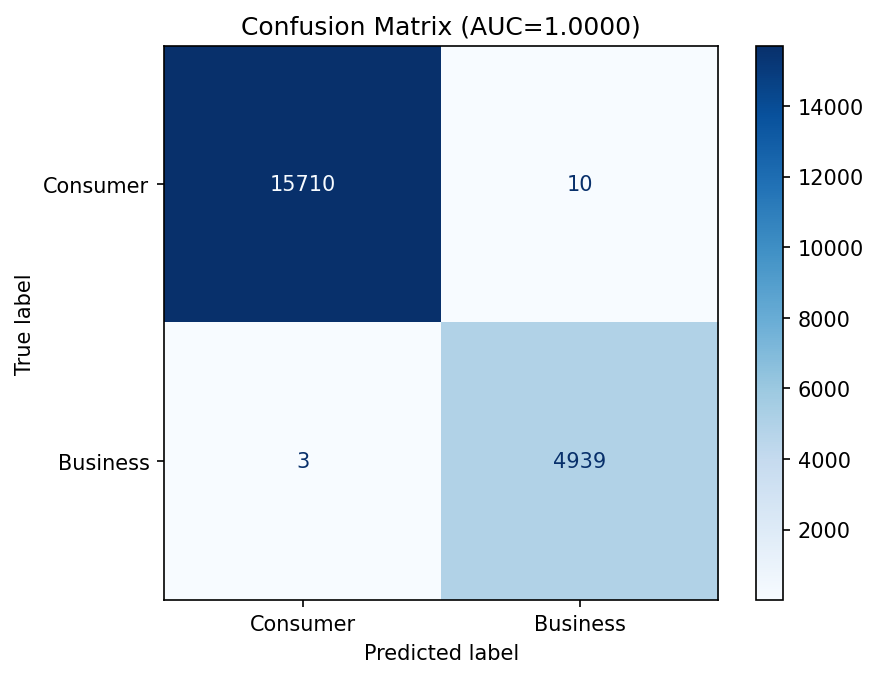

In [56]:
ConfusionMatrixDisplay.from_estimator(model,X_test,y_test,display_labels=["Consumer","Business"],cmap="Blues")
plt.title(f"Confusion Matrix (AUC={auc:.4f})")
plt.savefig(DATA_DIR/"confusion_matrix.png",dpi=150,bbox_inches="tight")
plt.show()
display(Image(filename=str(DATA_DIR/"confusion_matrix.png")))

## Step 9 — Feature Importance

Top 10:
  1. tokenized_ratio               28.17%  ||||||||||||||
  2. online_ratio                  11.97%  |||||
  3. b2b_volume_no_recurring       11.42%  |||||
  4. channel_alternation_rate       6.71%  |||
  5. channel_entropy                5.65%  ||
  6. txns_per_merchant              5.44%  ||
  7. vendor_concentration           4.17%  ||
  8. wholesale_spend_ratio          2.96%  |
  9. cb_spend_share                 2.56%  |
  10. cb_ratio                       2.55%  |


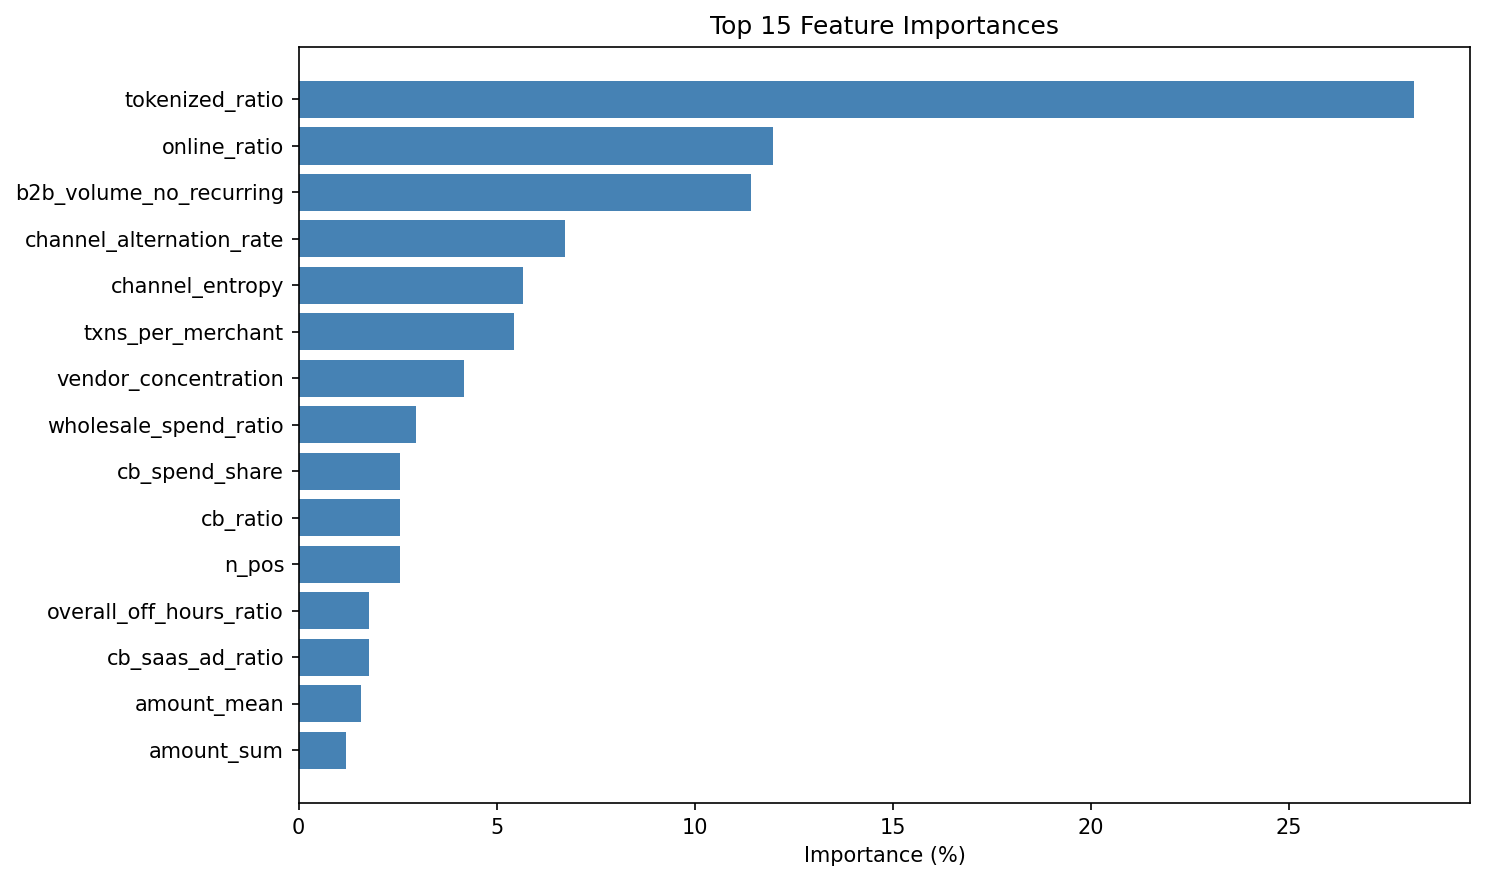

In [57]:
fi=pd.DataFrame({"feature":feature_names,"importance":model.feature_importances_}).sort_values("importance",ascending=False)
print("Top 10:")
for i,(_,r) in enumerate(fi.head(10).iterrows(),1):
    bar="|"*int(r["importance"]/2)
    print(f"  {i}. {r['feature']:<28s} {r['importance']:6.2f}%  {bar}")
plt.figure(figsize=(10,6)); top=fi.head(15)
plt.barh(range(len(top)),top["importance"].values,color="steelblue")
plt.yticks(range(len(top)),top["feature"].values); plt.gca().invert_yaxis()
plt.xlabel("Importance (%)"); plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.savefig(DATA_DIR/"feature_importance.png",dpi=150,bbox_inches="tight")
plt.show()
display(Image(filename=str(DATA_DIR/"feature_importance.png")))

## Step 10 — SHAP

Computing SHAP...


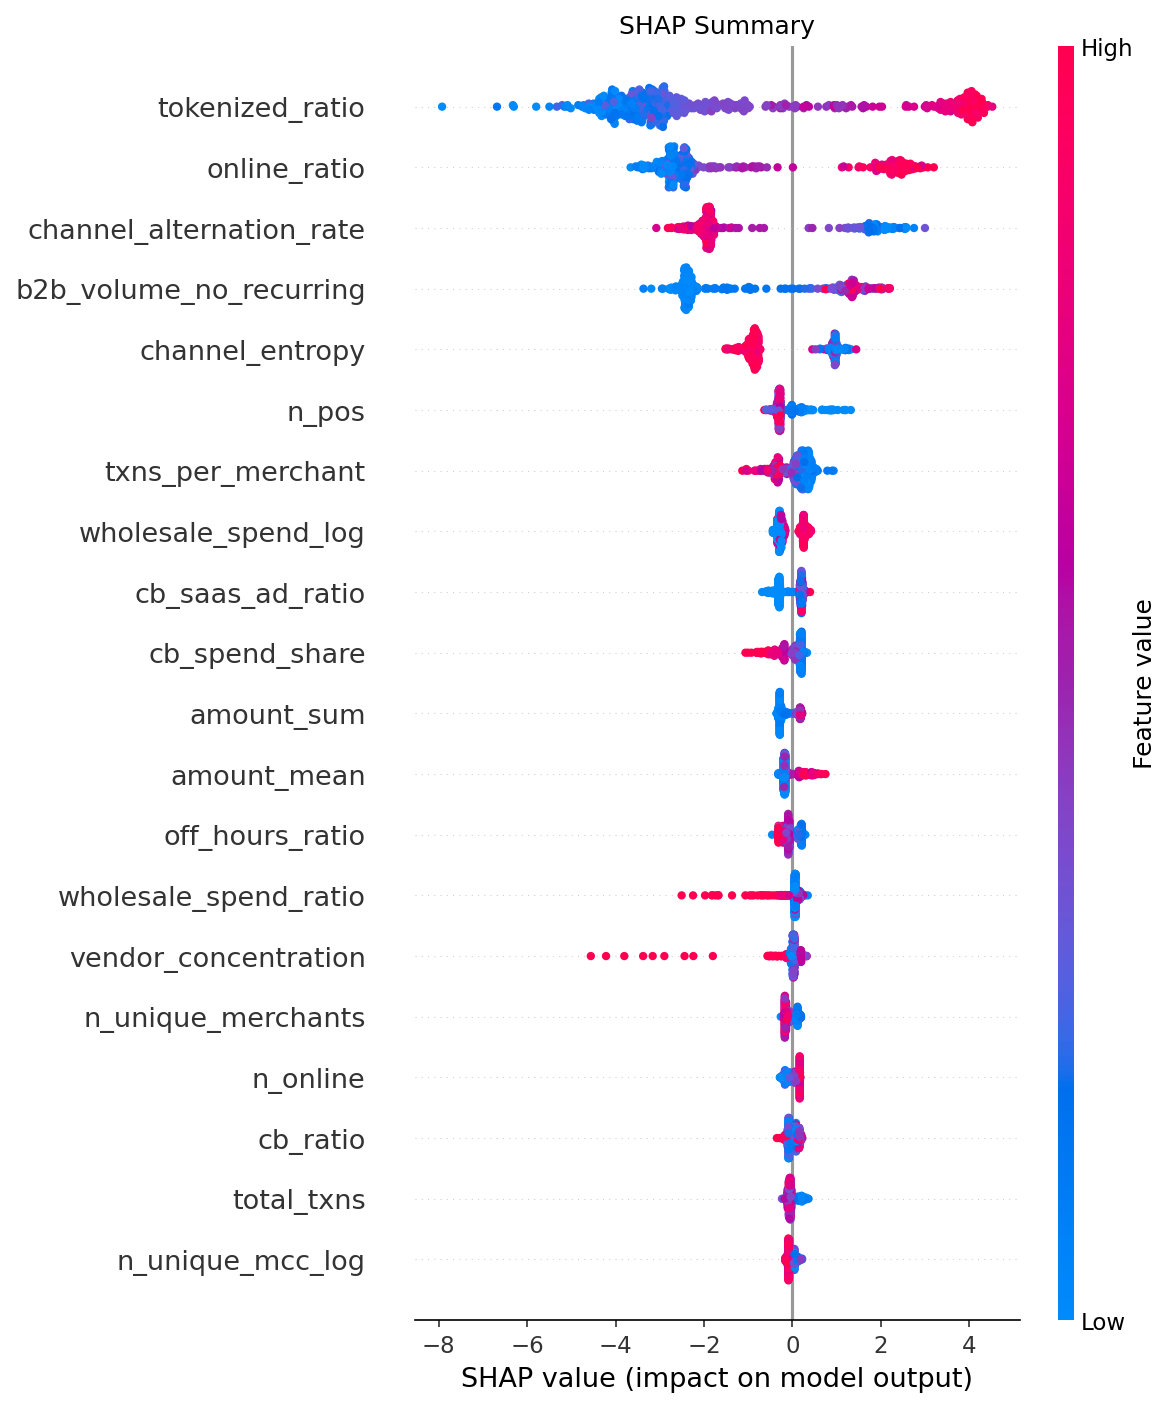

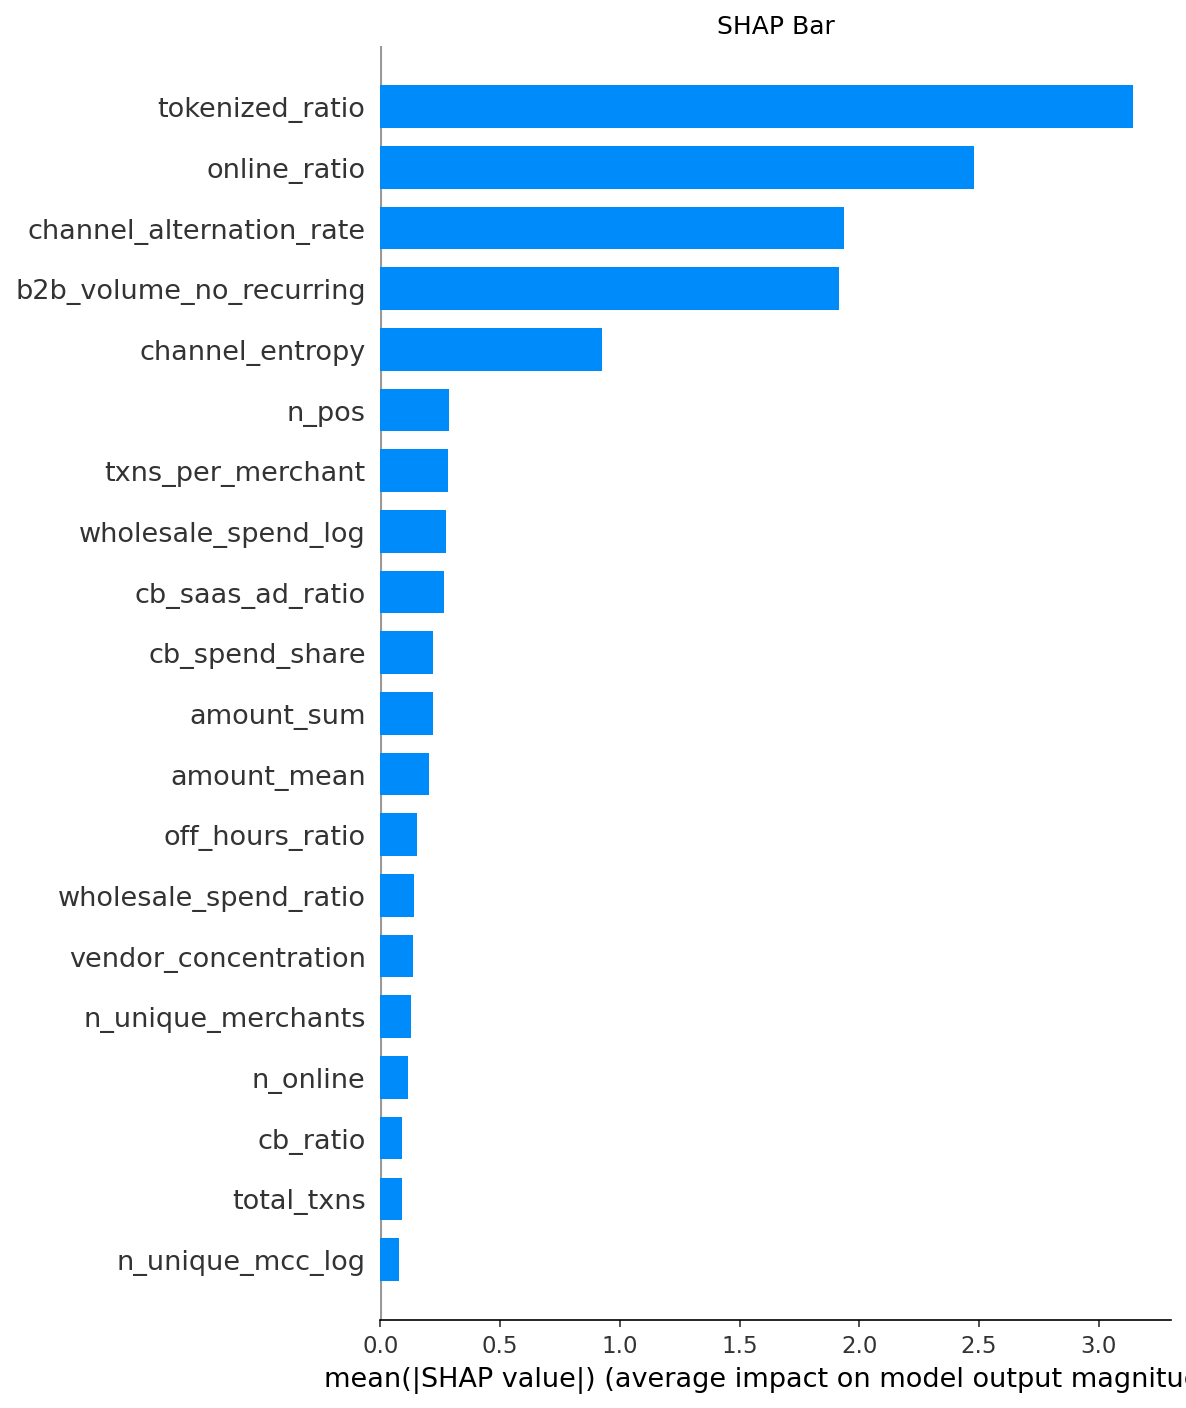

In [58]:
# SHAP explains WHY each card scored the way it did. We run on 500
# test samples for speed. Summary plot = feature impact direction.
# Bar plot = mean |SHAP| per feature.
print("Computing SHAP...")
test_df=pd.DataFrame(X_test[:500],columns=feature_names)
explainer=shap.TreeExplainer(model); shap_values=explainer.shap_values(test_df)
plt.figure(figsize=(12,8))
shap.summary_plot(shap_values,test_df,show=False)
plt.title("SHAP Summary")
plt.tight_layout(); plt.savefig(DATA_DIR/"shap_summary.png",dpi=150,bbox_inches="tight"); plt.show()
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values,test_df,plot_type="bar",show=False)
plt.title("SHAP Bar")
plt.tight_layout(); plt.savefig(DATA_DIR/"shap_bar.png",dpi=150,bbox_inches="tight"); plt.show()
display(Image(filename=str(DATA_DIR/"shap_summary.png")))
display(Image(filename=str(DATA_DIR/"shap_bar.png")))

## Step 11 — Top 100 + Target Product
- B2B Cashback - high wholesale_spend_ratio
- Working Capital Loan - high clockwork regularity
- Merchant Account - high channel_alternation_rate
- Business Credit Card - default

In [59]:
# Score all 80K consumer cards, pick top-100. Assign product based on
# strongest behavioral signal relative to consumer median thresholds.
consumer_mask=labels==0; consumer_feat=feat.loc[consumer_mask]
consumer_cards=consumer_feat.index.values
consumer_probas=model.predict_proba(consumer_feat.values)[:,1]
idx=np.argsort(consumer_probas)[-100:][::-1]
top_cards=consumer_cards[idx]; top_scores=consumer_probas[idx]
fc=feat.loc[consumer_mask]
cv_th=fc["clockwork_cv_mean"].median(); ws_th=fc["wholesale_spend_ratio"].median(); sch_th=fc["channel_alternation_rate"].median()
top_cv=fc.loc[top_cards,"clockwork_cv_mean"]; top_ws=fc.loc[top_cards,"wholesale_spend_ratio"]; top_sch=fc.loc[top_cards,"channel_alternation_rate"]
prods=[]
for i in range(100):
    if top_ws.iloc[i]>ws_th: prods.append("B2B Cashback")
    elif top_cv.iloc[i]>cv_th: prods.append("Working Capital Loan")
    elif top_sch.iloc[i]>sch_th: prods.append("Merchant Account")
    else: prods.append("Business Credit Card")
top_df=pd.DataFrame({"card_number":top_cards,"business_probability":top_scores,"rank":range(1,101),"recommended_product":prods})
print("Top 10:"); print(top_df.head(10).to_string(index=False))
top_df.to_csv(DATA_DIR/"top100_hidden_entrepreneurs.csv",index=False)
print(f"Saved -> top100_hidden_entrepreneurs.csv ({len(top_df)} records)")
for q in [0,25,50,75,90,95,99,100]:
    print(f"  P{q:>3}: {np.percentile(consumer_probas,q):.4f}")
print(f"Cards >0.5: {(consumer_probas>0.5).sum():,}/{len(consumer_probas):,}")
print(f"Products:\n{top_df['recommended_product'].value_counts().to_string()}")

Top 10:
     card_number  business_probability  rank recommended_product
5338471341634876              0.957324     1        B2B Cashback
5176515772256834              0.947180     2        B2B Cashback
5211559664892162              0.875335     3        B2B Cashback
5531519611861473              0.830538     4        B2B Cashback
5228597581598695              0.826179     5        B2B Cashback
5201491354169846              0.797457     6        B2B Cashback
5228590358308752              0.783736     7        B2B Cashback
5100610928479892              0.782513     8        B2B Cashback
5176512842972466              0.775588     9        B2B Cashback
5402339951548606              0.716256    10        B2B Cashback
Saved -> top100_hidden_entrepreneurs.csv (100 records)
  P  0: 0.0000
  P 25: 0.0000
  P 50: 0.0000
  P 75: 0.0000
  P 90: 0.0002
  P 95: 0.0005
  P 99: 0.0079
  P100: 0.9573
Cards >0.5: 21/78,599
Products:
recommended_product
B2B Cashback            72
Business Credit Card   

## Step 12 — Deliverables

In [60]:
import os
files=["confusion_matrix.png","feature_importance.png","shap_summary.png","shap_bar.png","top100_hidden_entrepreneurs.csv"]
print("Deliverables:")
for f in files:
    p=DATA_DIR/f; e=os.path.exists(p)
    print(f"  {'OK' if e else 'MISSING':8} {f:<40s} {os.path.getsize(p) if e else 0:>8,} bytes")
print("\nAll done.")

Deliverables:
  OK       confusion_matrix.png                       36,774 bytes
  OK       feature_importance.png                     58,262 bytes
  OK       shap_summary.png                          182,689 bytes
  OK       shap_bar.png                               91,472 bytes
  OK       top100_hidden_entrepreneurs.csv             5,613 bytes

All done.
